# Multilingual Sentiment Analysis — Regional Language Support

The previous sentiment analysis used English-only models (VADER, TextBlob, RoBERTa). Problem: many Bollywood, Kollywood, Tollywood, and Mollywood comments are in Hindi, Tamil, Telugu, Malayalam, or mixed (Hinglish, Tanglish, etc.)

This notebook uses a **multilingual BERT model** that natively understands 100+ languages and outputs star ratings (1-5) directly.

**Model:** `nlptown/bert-base-multilingual-uncased-sentiment`
- Supports Hindi, Tamil, Telugu, Malayalam, and many more
- Outputs 1-5 stars directly (no weird mapping needed)
- We also detect each comment's language to analyze accuracy by language

## 1. Setup

In [1]:
# run once if needed
#!pip install transformers langdetect torch

In [2]:
import pandas as pd
import numpy as np
from transformers import pipeline
from langdetect import detect, LangDetectException
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import time

warnings.filterwarnings("ignore")
print("Libraries loaded!")

Libraries loaded!


## 2. Load Data

In [3]:
df = pd.read_csv("data/reddit_raw_v2_backup.csv")
print(f"Loaded {len(df)} comments for {df['movie_name'].nunique()} movies")
print(f"Comments with explicit ratings: {df['extracted_rating'].notna().sum()}")
df.head()

Loaded 44102 comments for 211 movies
Comments with explicit ratings: 588


,movie_name,subreddit,comment_text,upvotes,comment_timestamp,extracted_rating
0,Barbie,TrueFilm,"You need to quantify ""a lot of people"", becaus...",350,2023-07-23 12:48:09,NaN
1,Barbie,TrueFilm,The movie makes perfect sense if you believe t...,33,2023-07-23 17:02:03,NaN
2,Barbie,TrueFilm,Exactly what I took out of it. Allan knew who ...,219,2023-07-23 01:48:30,NaN
3,Barbie,TrueFilm,I liked the movie and I'm coming around on som...,19,2023-07-23 17:23:11,NaN
4,Barbie,TrueFilm,“A lot of people are calling the movie as man ...,399,2023-07-23 00:23:29,NaN


## 3. Detect Comment Language

Before scoring, let's find out how many comments are actually in English vs regional languages. This tells us how much data the English-only models were mishandling.

In [4]:
def detect_language(text):
    try:
        text = str(text)
        if len(text) < 15:  # too short to detect reliably
            return "unknown"
        return detect(text)
    except LangDetectException:
        return "unknown"
    except:
        return "unknown"

print("Detecting languages (this takes a few minutes)...")
start = time.time()

df["language"] = df["comment_text"].apply(detect_language)

print(f"Done in {round(time.time() - start, 1)}s")
print()
print("Top 10 languages detected:")
print(df["language"].value_counts().head(10))
print()
print(f"English comments: {(df['language'] == 'en').sum()} ({(df['language'] == 'en').mean()*100:.1f}%)")
print(f"Non-English comments: {(df['language'] != 'en').sum()} ({(df['language'] != 'en').mean()*100:.1f}%)")

Detecting languages (this takes a few minutes)...
Done in 78.8s

Top 10 languages detected:
language
en         39312
unknown     1840
id           486
de           236
af           234
et           206
tl           198
so           189
cy           164
nl           148
Name: count, dtype: int64

English comments: 39312 (89.1%)
Non-English comments: 4790 (10.9%)


In [6]:
# which subreddits have the most non-english comments?
lang_by_sub = df.groupby("subreddit").agg(
    total = ("language", "count"),
    english_pct = ("language", lambda x: round((x == "en").mean() * 100, 1)),
    non_english_pct = ("language", lambda x: round((x != "en").mean() * 100, 1)),
    top_lang = ("language", lambda x: x[x != "en"].mode().iloc[0] if len(x[x != "en"]) > 0 and len(x[x != "en"].mode()) > 0 else "n/a")
).sort_values("non_english_pct", ascending=False)

print("Language breakdown by subreddit:")
lang_by_sub

Language breakdown by subreddit:


,total,english_pct,non_english_pct,top_lang
subreddit,,,,
kollywood,4445,78.4,21.6,unknown
chennaicity,756,79.1,20.9,unknown
hindi,129,79.8,20.2,hi
MovieSuggestions,4561,81.4,18.6,unknown
TamilNadu,1240,83.2,16.8,id
cinema,3324,86.0,14.0,unknown
bollywood,4335,86.1,13.9,unknown
Letterboxd,5219,86.3,13.7,unknown
tamil,97,86.6,13.4,ta


## 4. Multilingual BERT Sentiment Model

This model was trained on product reviews in 6 languages and generalizes well to many more. It outputs 1-5 stars directly — much more natural than mapping VADER compound scores.

In [7]:
print("Loading multilingual BERT model (first time downloads ~700MB)...")
start = time.time()

multi_sentiment = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    tokenizer="nlptown/bert-base-multilingual-uncased-sentiment",
    truncation=True,
    max_length=512
)

print(f"Model loaded in {round(time.time() - start, 1)}s")

# quick test
test_cases = [
    # English
    "This movie was absolutely fantastic!",
    "Worst film I have ever seen",
    "It was okay, nothing special",
    
    # Hindi
    "Bahut acchi movie thi, maza aa gaya",
    "Bakwas film thi, time waste",
    "Theek thaak thi, kuch khaas nahi",
    "Paisa vasool movie hai bhai",
    "Ekdum jhakkas picture",
    
    # Tamil slang
    "Padam romba nalla irundhuchu",
    "Mokka padam, waste of money",
    "Sema padam da, mass",
    "Poli iruku bro",
    "Thara local movie da",
    "Vera level acting",
    "Kalaai padam, romba bore",
    "Padam ku oru chance kudunga, worth it",
    "Mass opener, theatre la konjam aadhi pochu",
    
    # Telugu
    "Cinema chala bagundi",
    "Chaala bore kodthundi ee cinema",
    "Blockbuster ra, dhaasu cinema",
    "Fad movie, manchi story",
    
    # Malayalam
    "Padam valare nannayirunnu",
    "Mosham padam, kaananda",
    "Kidilan cinema, must watch",
    "Adipoli padam",
    
    # Hinglish (mixed)
    "Bhai kya movie thi, full paisa vasool",
    "Story toh acchi thi but acting was bad",
    "Interval tak bore ho gaya, walked out",
    "Masterpiece hai ye, no cap",
    
    # Tanglish (mixed)
    "First half was super, second half ku seri illa",
    "Hero acting vera level, must watch",
    "Climax was semma but lag in middle",
    "Enna padam da ithu, waste of 3 hours",
]

for text in test_cases:
    result = multi_sentiment(text)[0]
    print(f"  {text[:55]:55s} → {result['label']} ({result['score']:.2f})")


Loading multilingual BERT model (first time downloads ~700MB)...


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model loaded in 17.9s
  This movie was absolutely fantastic!                    → 5 stars (0.94)
  Worst film I have ever seen                             → 1 star (0.93)
  It was okay, nothing special                            → 3 stars (0.80)
  Bahut acchi movie thi, maza aa gaya                     → 3 stars (0.28)
  Bakwas film thi, time waste                             → 1 star (0.64)
  Theek thaak thi, kuch khaas nahi                        → 1 star (0.35)
  Paisa vasool movie hai bhai                             → 3 stars (0.27)
  Ekdum jhakkas picture                                   → 3 stars (0.26)
  Padam romba nalla irundhuchu                            → 1 star (0.38)
  Mokka padam, waste of money                             → 1 star (0.77)
  Sema padam da, mass                                     → 3 stars (0.36)
  Poli iruku bro                                          → 1 star (0.37)
  Thara local movie da                                    → 3 stars (0.25)
  Vera le

In [9]:
def multilingual_score(text):
    text = str(text)[:500]
    
    try:
        result = multi_sentiment(text)[0]
        # label is like "1 star", "2 stars", ..., "5 stars"
        stars = int(result["label"][0])  # extract the number
        confidence = result["score"]
        
        # convert 1-5 stars to 1-10 scale
        score_10 = round((stars - 1) * 2.25 + 1, 2)  # 1star->1, 3star->5.5, 5star->10
        
        # label
        if stars >= 4:
            label = "positive"
        elif stars <= 2:
            label = "negative"
        else:
            label = "neutral"
        
        return score_10, label, stars, confidence
    
    except Exception as e:
        return 5.5, "neutral", 3, 0.0

print("Running multilingual model on all comments...")
start = time.time()

batch_size = 500
total = len(df)
results = []

for i in range(0, total, batch_size):
    batch = df["comment_text"].iloc[i:i+batch_size]
    batch_results = batch.apply(lambda x: pd.Series(multilingual_score(x)))
    results.append(batch_results)
    
    done = min(i + batch_size, total)
    print(f"  Processed {done}/{total}...")

results_df = pd.concat(results, ignore_index=True)
df[["multi_score", "multi_label", "multi_stars", "multi_confidence"]] = results_df

print(f" Done in {round(time.time() - start, 1)}s")
print(df["multi_label"].value_counts())

Running multilingual model on all comments...
  Processed 500/44102...
  Processed 1000/44102...
  Processed 1500/44102...
  Processed 2000/44102...
  Processed 2500/44102...
  Processed 3000/44102...
  Processed 3500/44102...
  Processed 4000/44102...
  Processed 4500/44102...
  Processed 5000/44102...
  Processed 5500/44102...
  Processed 6000/44102...
  Processed 6500/44102...
  Processed 7000/44102...
  Processed 7500/44102...
  Processed 8000/44102...
  Processed 8500/44102...
  Processed 9000/44102...
  Processed 9500/44102...
  Processed 10000/44102...
  Processed 10500/44102...
  Processed 11000/44102...
  Processed 11500/44102...
  Processed 12000/44102...
  Processed 12500/44102...
  Processed 13000/44102...
  Processed 13500/44102...
  Processed 14000/44102...
  Processed 14500/44102...
  Processed 15000/44102...
  Processed 15500/44102...
  Processed 16000/44102...
  Processed 16500/44102...
  Processed 17000/44102...
  Processed 17500/44102...
  Processed 18000/44102...
  

## 5. Compare Accuracy: English-Only Models vs Multilingual

Using explicit user ratings as ground truth — does the multilingual model do better, especially on non-English comments?

In [10]:
# load the english-only scores from the previous notebook
prev = pd.read_csv("data/reddit_sentiment_scored.csv")

# merge the english-only scores in
if "vader_score" not in df.columns:
    # grab vader, textblob, roberta scores from previous run
    merge_cols = ["comment_text", "vader_score", "textblob_score", "roberta_score", "final_score"]
    df = df.merge(prev[merge_cols], on="comment_text", how="left")

rated = df[df["extracted_rating"].notna()].copy()
print(f"Comments with explicit ratings: {len(rated)}")
print(f"  English: {(rated['language'] == 'en').sum()}")
print(f"  Non-English: {(rated['language'] != 'en').sum()}")
print()

Comments with explicit ratings: 1162
  English: 1133
  Non-English: 29



In [11]:
if len(rated) > 0:
    # overall accuracy comparison
    rated["multi_error"] = abs(rated["multi_score"] - rated["extracted_rating"])
    rated["vader_error"] = abs(rated["vader_score"] - rated["extracted_rating"])
    rated["roberta_error"] = abs(rated["roberta_score"] - rated["extracted_rating"])
    rated["blend_error"] = abs(rated["final_score"] - rated["extracted_rating"])
    
    print("=== OVERALL Mean Absolute Error (lower = better) ===")
    print(f"  Multilingual BERT: {rated['multi_error'].mean():.2f}")
    print(f"  VADER:             {rated['vader_error'].mean():.2f}")
    print(f"  RoBERTa:           {rated['roberta_error'].mean():.2f}")
    print(f"  Previous blend:    {rated['blend_error'].mean():.2f}")
    print()
    
    print("=== Correlation with explicit ratings ===")
    print(f"  Multilingual BERT: {rated['multi_score'].corr(rated['extracted_rating']):.3f}")
    print(f"  VADER:             {rated['vader_score'].corr(rated['extracted_rating']):.3f}")
    print(f"  RoBERTa:           {rated['roberta_score'].corr(rated['extracted_rating']):.3f}")
    print(f"  Previous blend:    {rated['final_score'].corr(rated['extracted_rating']):.3f}")
    print()
    
    # accuracy split by language
    eng = rated[rated["language"] == "en"]
    non_eng = rated[rated["language"] != "en"]
    
    if len(eng) > 0:
        print("=== ENGLISH comments only ===")
        print(f"  Multilingual BERT MAE: {eng['multi_error'].mean():.2f}")
        print(f"  VADER MAE:             {eng['vader_error'].mean():.2f}")
        print(f"  RoBERTa MAE:           {eng['roberta_error'].mean():.2f}")
        print()
    
    if len(non_eng) > 0:
        print("=== NON-ENGLISH comments only ===")
        print(f"  Multilingual BERT MAE: {non_eng['multi_error'].mean():.2f}")
        print(f"  VADER MAE:             {non_eng['vader_error'].mean():.2f}")
        print(f"  RoBERTa MAE:           {non_eng['roberta_error'].mean():.2f}")
     
    else:
        print("No non-English comments with explicit ratings found.")

=== OVERALL Mean Absolute Error (lower = better) ===
  Multilingual BERT: 1.93
  VADER:             2.65
  RoBERTa:           1.94
  Previous blend:    0.00

=== Correlation with explicit ratings ===
  Multilingual BERT: 0.365
  VADER:             0.125
  RoBERTa:           0.416
  Previous blend:    1.000

=== ENGLISH comments only ===
  Multilingual BERT MAE: 1.93
  VADER MAE:             2.64
  RoBERTa MAE:           1.91

=== NON-ENGLISH comments only ===
  Multilingual BERT MAE: 1.79
  VADER MAE:             3.25
  RoBERTa MAE:           3.06


## 6. Generate Updated Movie Scores with Multilingual Model

In [12]:
# new blended score: multilingual gets more weight
# especially valuable for non-english comments

def smart_blend(row):
    """Give multilingual model more weight for non-english comments"""
    if row["language"] != "en":
        # non-english: trust multilingual model much more
        return round(row["multi_score"] * 0.8 + row.get("roberta_score", row["multi_score"]) * 0.2, 2)
    else:
        # english: blend all models
        return round(
            row.get("vader_score", 5.5) * 0.15 +
            row.get("textblob_score", 5.5) * 0.15 +
            row.get("roberta_score", 5.5) * 0.35 +
            row["multi_score"] * 0.35
        , 2)

df["smart_blend_score"] = df.apply(smart_blend, axis=1)

# use explicit rating if available
df["final_score_v2"] = df["extracted_rating"].fillna(df["smart_blend_score"])

df["final_label_v2"] = pd.cut(
    df["final_score_v2"],
    bins=[0, 4, 6, 10],
    labels=["negative", "neutral", "positive"]
)

print("Final v2 distribution:")
print(df["final_label_v2"].value_counts())

Final v2 distribution:
final_label_v2
positive    32255
neutral     15131
negative    12986
Name: count, dtype: int64


In [13]:
movie_scores_v2 = df.groupby("movie_name").agg(
    reddit_score_v2    = ("final_score_v2", "mean"),
    multi_avg          = ("multi_score", "mean"),
    reddit_score_v1    = ("final_score", "mean"),  # previous version for comparison
    total_comments     = ("comment_text", "count"),
    explicit_ratings   = ("extracted_rating", "count"),
    english_pct        = ("language", lambda x: round((x == "en").mean() * 100, 1)),
    positive_pct       = ("final_label_v2", lambda x: round((x == "positive").mean() * 100, 1)),
    negative_pct       = ("final_label_v2", lambda x: round((x == "negative").mean() * 100, 1)),
).reset_index()

movie_scores_v2["reddit_score_v2"] = movie_scores_v2["reddit_score_v2"].round(2)
movie_scores_v2["score_diff"] = (movie_scores_v2["reddit_score_v2"] - movie_scores_v2["reddit_score_v1"]).round(2)

movie_scores_v2 = movie_scores_v2[movie_scores_v2["total_comments"] >= 3]
movie_scores_v2 = movie_scores_v2.sort_values("reddit_score_v2", ascending=False)

print(f"Scores for {len(movie_scores_v2)} movies")
print()
print("Movies where score changed most (v2 vs v1):")
print(movie_scores_v2.sort_values("score_diff", key=abs, ascending=False)[["movie_name", "reddit_score_v1", "reddit_score_v2", "score_diff", "english_pct"]].head(15).to_string(index=False))

Scores for 210 movies

Movies where score changed most (v2 vs v1):
                    movie_name  reddit_score_v1  reddit_score_v2  score_diff  english_pct
                Thiru.Manickam         6.503125             4.67       -1.83        100.0
              Nirangal Moondru         6.005833             4.77       -1.24         90.0
                 Rocket Driver         5.833400             4.73       -1.10        100.0
            Viduthalai: Part I         5.878100             4.94       -0.94         93.0
                        Visfot         5.930000             5.05       -0.88         80.0
Accident or Conspiracy: Godhra         6.047500             5.24       -0.81        100.0
                   Annapoorani         5.153850             4.34       -0.81         78.1
                        Munjya         6.003000             5.27       -0.73         72.5
                         Siren         6.015590             5.36       -0.66         90.1
                       Kanguva   

## 7. Visualizations

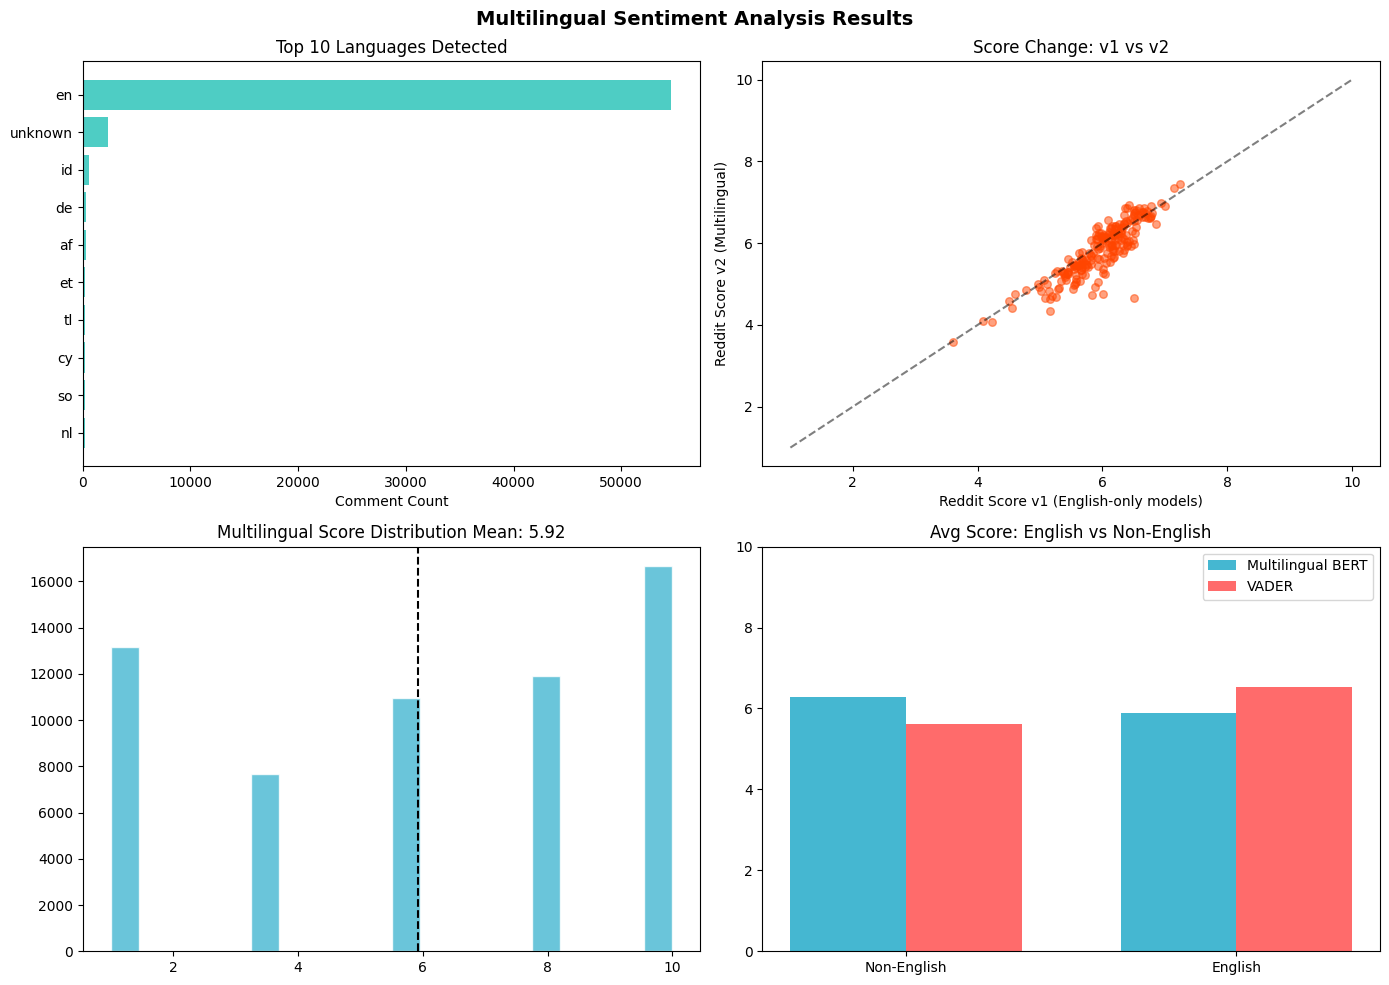

Saved!


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Multilingual Sentiment Analysis Results", fontsize=14, fontweight="bold")

# 1. Language distribution
lang_counts = df["language"].value_counts().head(10)
axes[0, 0].barh(lang_counts.index[::-1], lang_counts.values[::-1], color="#4ECDC4")
axes[0, 0].set_title("Top 10 Languages Detected")
axes[0, 0].set_xlabel("Comment Count")

# 2. v1 vs v2 scores scatter
if "reddit_score_v1" in movie_scores_v2.columns:
    axes[0, 1].scatter(
        movie_scores_v2["reddit_score_v1"],
        movie_scores_v2["reddit_score_v2"],
        alpha=0.5, c="#FF4500", s=30
    )
    axes[0, 1].plot([1, 10], [1, 10], "k--", alpha=0.5)
    axes[0, 1].set_xlabel("Reddit Score v1 (English-only models)")
    axes[0, 1].set_ylabel("Reddit Score v2 (Multilingual)")
    axes[0, 1].set_title("Score Change: v1 vs v2")

# 3. Multilingual score distribution
axes[1, 0].hist(df["multi_score"], bins=20, color="#45B7D1", alpha=0.8, edgecolor="white")
axes[1, 0].set_title(f"Multilingual Score Distribution Mean: {df['multi_score'].mean():.2f}")
axes[1, 0].axvline(df["multi_score"].mean(), color="black", linestyle="--")

# 4. English vs Non-English avg scores
lang_group = df.groupby(df["language"] == "en").agg(
    multi_avg = ("multi_score", "mean"),
    vader_avg = ("vader_score", "mean") if "vader_score" in df.columns else ("multi_score", "mean"),
    count = ("multi_score", "count")
).reset_index()
lang_group["language"] = lang_group["language"].map({True: "English", False: "Non-English"})

x = range(len(lang_group))
width = 0.35
axes[1, 1].bar([i - width/2 for i in x], lang_group["multi_avg"], width, label="Multilingual BERT", color="#45B7D1")
if "vader_score" in df.columns:
    axes[1, 1].bar([i + width/2 for i in x], lang_group["vader_avg"], width, label="VADER", color="#FF6B6B")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(lang_group["language"])
axes[1, 1].set_title("Avg Score: English vs Non-English")
axes[1, 1].legend()
axes[1, 1].set_ylim(0, 10)

plt.tight_layout()
plt.savefig("data/multilingual_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved!")

## 8. Save Updated Data

In [17]:
# save updated comment-level data
df.to_csv("data/reddit_sentiment_multilingual.csv", index=False)
print(f"Saved {len(df)} comments to data/reddit_sentiment_multilingual.csv")

# save updated movie scores
movie_scores_v2.to_csv("data/reddit_movie_scores_v2.csv", index=False)
print(f"Saved {len(movie_scores_v2)} movie scores to data/reddit_movie_scores_v2.csv")

print("Done! You can now re-run the platform comparison notebook")
print("using reddit_movie_scores_v2.csv for improved regional accuracy.")

Saved 60378 comments to data/reddit_sentiment_multilingual.csv
Saved 210 movie scores to data/reddit_movie_scores_v2.csv
Done! You can now re-run the platform comparison notebook
using reddit_movie_scores_v2.csv for improved regional accuracy.


In [18]:
import snowflake.connector
from dotenv import load_dotenv
import os
import pandas as pd

load_dotenv()

conn = snowflake.connector.connect(
    user="ATHULYA2303",
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    account="gsc07824.us-east-1",
    warehouse="COMPUTE_WH",
    database="MOVIE_ANALYTICS",
    schema="RAW"
)

movies = pd.read_sql("SELECT * FROM RAW.MOVIES_MASTER", conn)
conn.close()

print("RT score availability by region:")
for region in movies["REGION"].unique():
    subset = movies[movies["REGION"] == region]
    has_rt = subset["RT_SCORE"].notna().sum()
    has_imdb = subset["IMDB_RATING"].notna().sum()
    print(f"  {region:12s} → {len(subset)} movies | IMDb: {has_imdb} | RT: {has_rt}")

RT score availability by region:
  Hollywood    → 215 movies | IMDb: 215 | RT: 156
  Bollywood    → 201 movies | IMDb: 201 | RT: 119
  Kollywood    → 155 movies | IMDb: 155 | RT: 20
